In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
#from random import sample
import warnings
import time

sns.set(color_codes=True)

from lifelines.plotting import plot_lifetimes      # Lifeline package for the Survival Analysis
%pylab inline
from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()

warnings.filterwarnings('ignore')
%matplotlib inline

Populating the interactive namespace from numpy and matplotlib


In [2]:
t = datetime.datetime.strptime("2020-W01-7", "%G-W%V-%u")
print(t)
t = datetime.datetime.strptime("2020-W01-7", "%G-W%V-%u")
print(t)

2020-01-05 00:00:00
2020-01-05 00:00:00


In [19]:
%run ./CVGI_MR_00_functions.ipynb

Populating the interactive namespace from numpy and matplotlib


In [20]:
imports()

What is the source of the MOVEMENT data? (1=internet, 2=home Mac, 3=office Windows)3
What type of import is it? (1 = initial (only cases and movement), 2 = initial (full), 3 = data by week, 4 = merged datasets, 5 = only cases)5

IN
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1185852 entries, 0 to 1185851
Data columns (total 8 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   date             1185852 non-null  object 
 1   GADM_GID_2       1185852 non-null  object 
 2   mun_name         1185852 non-null  object 
 3   movement_change  1185852 non-null  float64
 4   stay_put         1185852 non-null  float64
 5   epi_week         1185852 non-null  object 
 6   ibge_code        1185852 non-null  int64  
 7   pop_2020         1185852 non-null  int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 72.4+ MB

+++++++++++++++++Movement Range, by epidemiological week+++++++++++++++++
 None
<class 'pandas.core.frame.DataFr

ImportError: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.

In [2]:
cases = clean_cases_by_epi_week(cases_by_epi_week_merged)
cases

NameError: name 'clean_cases_by_epi_week' is not defined

---

In [6]:
events_rs = events_uf('43')
events_rs

event  week
4300034 0     1.0  38.0
        1     1.0  38.0
        2     1.0  39.0
        3     1.0  40.0
4300059 0     1.0  17.0
...           ...   ...
4323804 35    1.0  52.0
        36    1.0  52.0
        37    1.0  54.0
        38    1.0  55.0
        39    1.0  56.0

[27640 rows x 2 columns]

getting the dataframes and plotting for SP, RJ and POA

In [ ]:
#RJ ibge_code == '3304557'
#SP ibge_code == '3550308'
#PA ibge_code == '4314902'

In [7]:
#preparing dataset for PA
city = '4314902'
cases_pa = cases[cases.ibge_code == city]
events_pa = events_cities(cases_pa)
events_pa

,event,week
0,1.0,2.0
1,1.0,2.0
2,1.0,3.0
3,1.0,3.0
4,1.0,4.0
...,...,...
4703,1.0,63.0
4704,1.0,63.0
4705,1.0,63.0
4706,1.0,63.0


In [44]:
#Checking if all deaths are accounted for
city = '4314902'
cases[cases.ibge_code == city].new_deaths.sum()

4708

In [28]:
#preparing dataset for RJ
city = '3304557'
cases_rj = cases[cases.ibge_code == city]
events_rj = events_cities(cases_rj)
events_rj

,event,week
0,1.0,3.0
1,1.0,3.0
2,1.0,3.0
3,1.0,3.0
4,1.0,3.0
...,...,...
25928,1.0,64.0
25929,1.0,64.0
25930,1.0,64.0
25931,1.0,64.0


In [29]:
#Checking if all deaths are accounted for
cases[cases.ibge_code == city].new_deaths.sum()

25933

In [30]:
#preparing dataset for SP
city = '3550308'
cases_sp = cases[cases.ibge_code == city]
events_sp = events_cities(cases_sp)
events_sp

,event,week
0,1.0,3.0
1,1.0,3.0
2,1.0,3.0
3,1.0,3.0
4,1.0,3.0
...,...,...
29875,1.0,65.0
29876,1.0,65.0
29877,1.0,65.0
29878,1.0,65.0


In [31]:
#Checking if all deaths are accounted for
cases[cases.ibge_code == city].new_deaths.sum()

29880

In [35]:
dict_events_cities = {}
dict_events_cities['4314902'] = events_cities(cases_pa)
dict_events_cities['3304557'] = events_cities(cases_rj)
dict_events_cities['3550308'] = events_cities(cases_sp)

{'4314902':       event  week
 0       1.0   2.0
 1       1.0   2.0
 2       1.0   3.0
 3       1.0   3.0
 4       1.0   4.0
 ...     ...   ...
 4703    1.0  63.0
 4704    1.0  63.0
 4705    1.0  63.0
 4706    1.0  63.0
 4707    1.0  63.0
 
 [4708 rows x 2 columns],
 '3304557':        event  week
 0        1.0   3.0
 1        1.0   3.0
 2        1.0   3.0
 3        1.0   3.0
 4        1.0   3.0
 ...      ...   ...
 25928    1.0  64.0
 25929    1.0  64.0
 25930    1.0  64.0
 25931    1.0  64.0
 25932    1.0  64.0
 
 [25933 rows x 2 columns],
 '3550308':        event  week
 0        1.0   3.0
 1        1.0   3.0
 2        1.0   3.0
 3        1.0   3.0
 4        1.0   3.0
 ...      ...   ...
 29875    1.0  65.0
 29876    1.0  65.0
 29877    1.0  65.0
 29878    1.0  65.0
 29879    1.0  65.0
 
 [29880 rows x 2 columns]}

In [37]:
df_events_cities = pd.concat(dict_events_cities)
df_events_cities

event  week
4314902 0        1.0   2.0
        1        1.0   2.0
        2        1.0   3.0
        3        1.0   3.0
        4        1.0   4.0
...              ...   ...
3550308 29875    1.0  65.0
        29876    1.0  65.0
        29877    1.0  65.0
        29878    1.0  65.0
        29879    1.0  65.0

[60521 rows x 2 columns]

In [34]:
%run ./CVGI_MR_00_functions.ipynb

Populating the interactive namespace from numpy and matplotlib


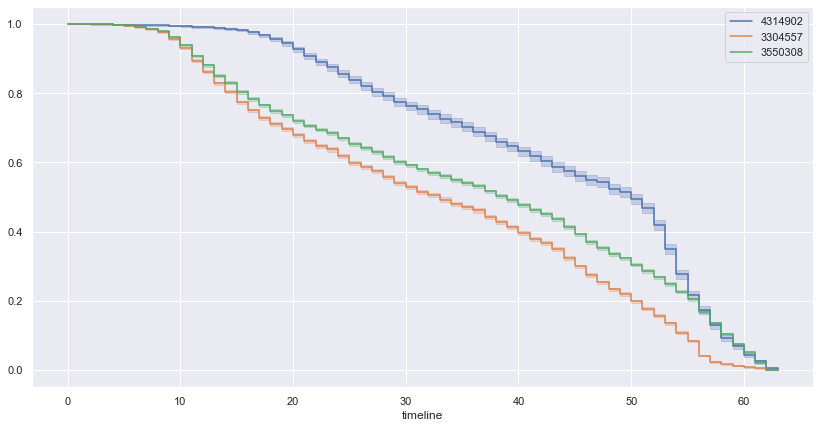

In [50]:
#RJ ibge_code == '3304557'
#SP ibge_code == '3550308'
#PA ibge_code == '4314902'
cities_list = ['4314902', '3304557','3550308'] 
kmf = plot_kmf(df_events_cities,cities_list)

In [54]:
kmf.median_survival_time_

39.0

---

<h4>Scenario A: Social Vulnerability Index</h4>
1. Select cities with lowest/highest SVI for each region region [list]
2. Prepare the dataframe of events for each city
3. Create a dict of highest SVI cities and of lowest SVI cities
4. Concatenate dict into 2 dataframes: events_svi_high and events_svi_low
5. Fit cases to Kaplan-Meier

In [ ]:
#Select cities based on SVI:


<h4>Scenario B: Municipal Human Development Index</h4>
1. Select cities with lowest/highest MHDI for each region region [list]
2. Prepare the dataframe of events for each city
3. Create a dict of highest MHDI cities and of lowest MHDI cities
4. Concatenate dict into 2 dataframes: events_mhdi_high and events_mhdi_low
5. Fit cases to Kaplan-Meier

<h4>Scenario C: COVID Mortality</h4>
1. Select cities with lowest/highest mortality rate per million for each region region [list]
2. Prepare the dataframe of events for each city
3. Create a dict of highest mortality rate cities and of lowest mortality rate cities
4. Concatenate dict into 2 dataframes: events_mort_high and events_mort_low
5. Fit cases to Kaplan-Meier

---

exploratory again

In [36]:
uf = '43'
cases[(cases['ibge_code'].str.startswith(uf))].ibge_code.unique()

array(['4300034', '4300059', '4300109', '4300208', '4300307', '4300406',
       '4300455', '4300471', '4300505', '4300554', '4300570', '4300604',
       '4300638', '4300646', '4300661', '4300703', '4300802', '4300851',
       '4300877', '4300901', '4301008', '4301057', '4301073', '4301107',
       '4301206', '4301305', '4301404', '4301503', '4301552', '4301602',
       '4301636', '4301651', '4301701', '4301750', '4301800', '4301859',
       '4301875', '4301909', '4301925', '4301958', '4302006', '4302055',
       '4302105', '4302154', '4302204', '4302220', '4302238', '4302253',
       '4302303', '4302352', '4302378', '4302402', '4302451', '4302501',
       '4302584', '4302600', '4302659', '4302709', '4302808', '4302907',
       '4303004', '4303103', '4303202', '4303301', '4303400', '4303509',
       '4303558', '4303608', '4303673', '4303707', '4303806', '4303905',
       '4304002', '4304101', '4304200', '4304309', '4304358', '4304408',
       '4304507', '4304606', '4304614', '4304622', 

In [ ]:
cities_list = ['4309050', '4314068','4314308','4315305','4313003','4312617'] 
kmf = plot_kmf(events_rs,cities_list)

In [39]:
cases.describe()

,acc_cases,acc_deaths,new_cases,new_deaths,pop_2019,acc_cases_100k,acc_deaths_1mi
count,3.080350e+05,308035.000000,308035.000000,308035.000000,3.080350e+05,308035.000000,308035.000000
mean,8.315155e+03,228.352197,52.007824,1.454666,4.121959e+04,19252.871498,3779.840029
std,5.641156e+04,2325.247722,329.669885,13.413192,2.399519e+05,20540.967376,4262.055788
min,0.000000e+00,0.000000,-2902.000000,-53.000000,7.810000e+02,0.000000,0.000000
25%,3.320000e+02,7.000000,1.000000,0.000000,5.678000e+03,3887.790000,479.215000
50%,1.373000e+03,28.000000,8.000000,0.000000,1.233700e+04,13141.580000,2546.840000
75%,4.496000e+03,91.000000,29.000000,1.000000,2.695200e+04,27776.030000,5585.910000
max,5.310756e+06,206285.000000,42546.000000,1401.000000,1.225202e+07,922404.370000,158860.270000


In [45]:
city = '4314902'
cases_pa = cases[cases.ibge_code == city]

In [48]:
uf = '43'
cases_rs = cases[(cases['ibge_code'].str.startswith(uf))]
cases_rs

,ibge_code,epi_week,acc_cases,acc_deaths,new_cases,new_deaths,pop_2019,epi_week_col,acc_cases_100k,acc_deaths_1mi,epi_week_date
256342,4300034,2020.29,1,0,0,0,4901.0,2020.29,20.40,0.00,2020-07-26
256343,4300034,2020.30,0,0,0,0,4901.0,2020.30,0.00,0.00,2020-08-02
256344,4300034,2020.31,0,0,0,0,4901.0,2020.31,0.00,0.00,2020-08-09
256345,4300034,2020.32,0,0,0,0,4901.0,2020.32,0.00,0.00,2020-08-16
256346,4300034,2020.33,0,0,0,0,4901.0,2020.33,0.00,0.00,2020-08-23
...,...,...,...,...,...,...,...,...,...,...,...
282897,4323804,2021.17,4972,239,47,2,16408.0,2021.17,30302.29,14566.07,2021-05-02
282898,4323804,2021.18,5415,245,99,0,16408.0,2021.18,33002.19,14931.74,2021-05-09
282899,4323804,2021.19,5950,249,29,1,16408.0,2021.19,36262.80,15175.52,2021-05-16
282900,4323804,2021.20,6082,256,4,1,16408.0,2021.20,37067.28,15602.15,2021-05-23


In [49]:
cases_rs.describe()

,acc_cases,acc_deaths,new_cases,new_deaths,pop_2019,acc_cases_100k,acc_deaths_1mi
count,26560.000000,26560.000000,26560.000000,26560.000000,2.656000e+04,26560.000000,26560.000000
mean,5472.635919,124.545708,40.145482,1.040060,2.558551e+04,21198.656223,3923.468125
std,26122.384886,771.615718,172.275357,6.153879,8.752490e+04,23910.385750,5129.155620
min,0.000000,0.000000,-28.000000,-1.000000,1.034000e+03,0.000000,0.000000
25%,182.000000,0.000000,1.000000,0.000000,3.018000e+03,3308.217500,0.000000
50%,740.000000,14.000000,5.000000,0.000000,5.981000e+03,13052.495000,2216.730000
75%,2604.000000,49.000000,22.000000,0.000000,1.829300e+04,31727.202500,5754.210000
max,869519.000000,32443.000000,9061.000000,342.000000,1.483771e+06,922404.370000,158860.270000


In [91]:
var = 'new_deaths'
cases_rs_clip1 = pd.DataFrame(cases_rs[[var,'epi_week_date','ibge_code']],index=cases_rs.index)
cases_rs_clip2 = cases_rs_clip1[cases_rs_clip1['ibge_code'].str.startswith('4314')]
cases_rs_clip2

,new_deaths,epi_week_date,ibge_code
272250,0,2020-04-05,4314001
272251,0,2020-04-12,4314001
272252,0,2020-04-19,4314001
272253,0,2020-04-26,4314001
272254,0,2020-05-03,4314001
...,...,...,...
273731,116,2021-05-02,4314902
273732,122,2021-05-09,4314902
273733,83,2021-05-16,4314902
273734,96,2021-05-23,4314902


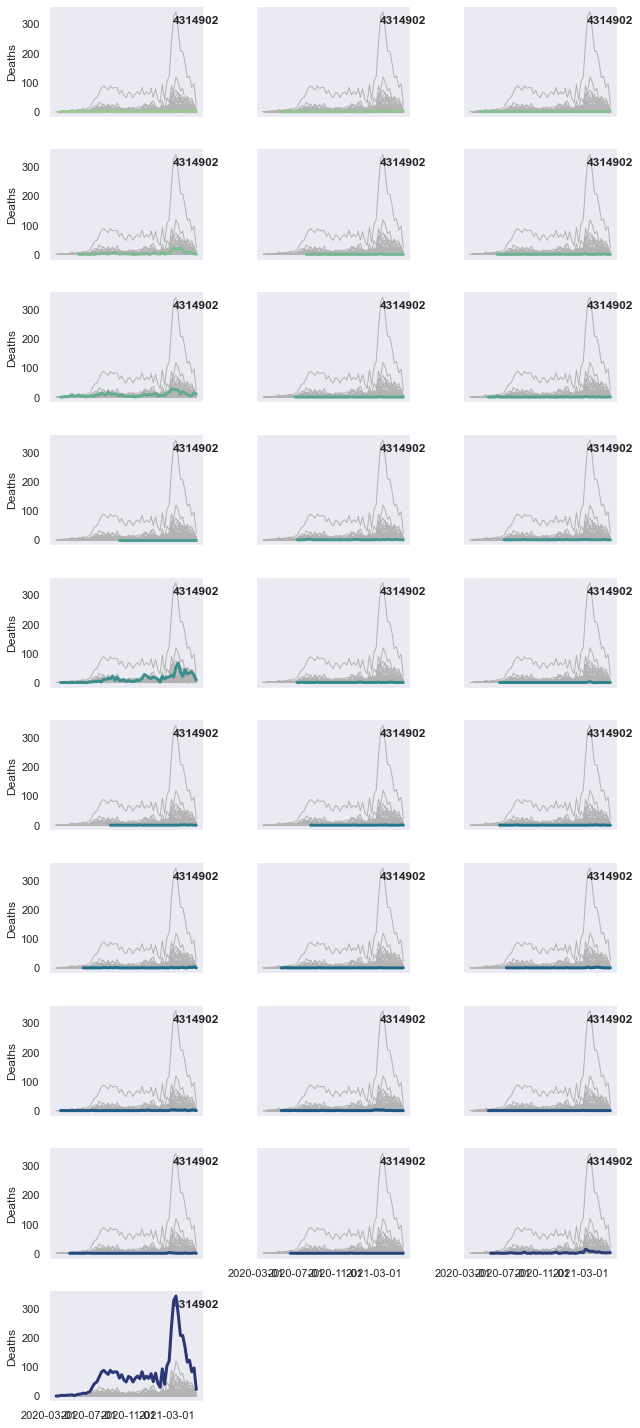

In [93]:
sns.set_theme(style="dark")

# Plot each year's time series in its own facet
g = sns.relplot(
    data=cases_rs_clip2,
    x="epi_week_date", y=var, col="ibge_code", hue="ibge_code",
    kind="line", palette="crest", linewidth=3, zorder=5,
    col_wrap=3, height=2, aspect=1.5, legend=False,
)
for city, ax in g.axes_dict.items():

    # Add the title as an annotation within the plot
    ax.text(.8, .85, year, transform=ax.transAxes, fontweight="bold")

    # Plot every city's time series in the background
    sns.lineplot(
        data=cases_rs_plot, x="epi_week_date", y=var, units="ibge_code",
        estimator=None, color=".7", linewidth=1, ax=ax,
    )
# Reduce the frequency of the x axis ticks
ax.set_xticks(ax.get_xticks()[::2])

# Tweak the supporting aspects of the plot
g.set_titles("")
g.set_axis_labels("", "Deaths")
g.tight_layout()

In [ ]:
cities_label = ibge_codes[ibge_codes.ibge_code == cities_list[i]].mun_name


In [ ]:
def plot_kmf_alt(dataframe,cities):
    kmf = KaplanMeierFitter() 
    df = dataframe
    #list currently takes a max of 5 cities because of the ax elements in the plot at the end
    cities_list = cities

    T = df['week']     ## time to event
    E = df['event']      ## event occurred or censored


    #creating a the cohorts. this takes a list of index (named) keys
    groups = df.loc[cities_list]
    #create an empty series object to receive the dataframe for each city below
    ix = pd.Series([])
    for i in range(len(cities_list)):
        #create a temporary dataframe, holding the events for each city
        ix[i] = groups.loc[cities_list[i]].index
        cities_label = cities_list[i]
        cities_label = ibge_codes[ibge_codes.ibge_code == cities_list[i]].mun_name
        #passing on the dataframe's time and event columns to the Kaplan-Meier function, and the index keys as labels (we can search the IBGE database for its name later)
        kmf.fit(T[ix[i]], E[ix[i]], label=cities_label)    ## fit the cohort 1 data
        figsize(14,7)
        if i == 0:
            ax = kmf.plot()
        elif i > 0:
            ax1 = kmf.plot(ax=ax)
    plt.show()
    return kmf